### Build A Basic Chatbot with Langgraph (GraphAPI)


In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    # Messages have the type 'list'. The 'add_messages' function 
    # in the annotation defines how this state key should be updated
    # (in this case, it appends the messages to the list, rahter than overwritting them)
    messages: Annotated[list, add_messages]


In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model= "llama-3.3-70b-versatile")

In [ ]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")

In [8]:
# Node Functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)

#Adding Nodes
graph_builder.add_node("llmchatbot", chatbot)

#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#Compile the Graph
graph = graph_builder.compile()

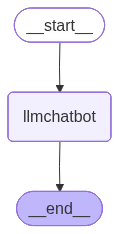

In [10]:
#isualize the graph 
from IPython.display import Image,display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({"messages":"Hi"})

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How about you? How's your day going so far?


### Chatbot With Tools 

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("wHat is LanGgraph?")

{'query': 'wHat is LanGgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by model

In [15]:
##Custom Function 
def multiply(a:int, b:int)-> int:
    """Multiply a and b 
    
    Args:
        a (int): first int 
        b (int): second int 
    
    Return:
        int: output int
    """
    return a*b

In [16]:
tools = [tool,multiply]

In [17]:
llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021A8795B3D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021A87AB0A00>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input

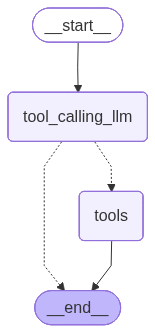

In [19]:
##StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition will route to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition will route to END
    tools_condition
)
builder.add_edge("tools", END)

## Compile the Graph
graph = builder.compile()

## Display the Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [20]:
response = graph.invoke({"messages": "What is the recent news on AI"})

In [21]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/openclaw-ai-demand-token-use-surge-nvidia-pricing-jumps-2026-2", "title": "There\'s been a surge in AI use recently. Here\'s what\'s behind it. - Business Insider", "score": 0.99469805, "published_date": "Thu, 19 Feb 2026 10:00:04 GMT", "content": "# There\'s been a surge in AI use recently. * AI token usage soared in recent weeks, while Nvidia GPU pricing has jumped. AI demand has surged in recent weeks, according to new data that could support tech giants\' decisions to dramatically ramp up investment in this area. AI models break down words and other inputs into numerical tokens to make them easier to process and understand. Anand Iyer, a partner at VC firm Lightspeed, said the recent surge has been driven by an explosion in AI agent activity and especially the rapid emergence of OpenClaw, an open-source agentic system. That\'s sparked an expon

In [22]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent news on AI
================================== Ai Message ==================================
Tool Calls:
  tavily_search (c8wejb3q0)
 Call ID: c8wejb3q0
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/openclaw-ai-demand-token-use-surge-nvidia-pricing-jumps-2026-2", "title": "There's been a surge in AI use recently. Here's what's behind it. - Business Insider", "score": 0.99469805, "published_date": "Thu, 19 Feb 2026 10:00:04 GMT", "content": "# There's been a surge in AI use recently. * AI token usage soared in recent weeks, while Nvidia GPU pricing has jumped. AI demand has surged in recent weeks, according to new data that co

In [23]:
response = graph.invoke({"messages": "What is 18 multiplied by 79"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 18 multiplied by 79
================================== Ai Message ==================================
Tool Calls:
  multiply (ppg3z0h5d)
 Call ID: ppg3z0h5d
  Args:
    a: 18
    b: 79
================================= Tool Message =================================
Name: multiply

1422


In [24]:
response = graph.invoke({"messages": "What is 5 multiplied by 2 then multiply by 5"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 then multiply by 5
================================== Ai Message ==================================
Tool Calls:
  multiply (ec7pcg2ds)
 Call ID: ec7pcg2ds
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [25]:
response = graph.invoke({"messages": "Give the recent news on AI in India and What is 2 multiplied by 81"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give the recent news on AI in India and What is 2 multiplied by 81
================================== Ai Message ==================================
Tool Calls:
  tavily_search (49n7z14wn)
 Call ID: 49n7z14wn
  Args:
    query: Recent news on AI in India
    topic: news
  multiply (bceyc67p9)
 Call ID: bceyc67p9
  Args:
    a: 2
    b: 81
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent news on AI in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.news18.com/business/markets/ai-adoption-in-india-gains-visibility-as-genpact-executive-highlights-workforce-shift-ws-l-9906190.html", "title": "AI Adoption In India Gains Visibility As Genpact Executive Highlights Workforce Shift - News18", "score": 0.9997508, "published_date": "Mon, 16 Feb 2026 06:22:15 GMT", "content": "# AI Adoption In Ind

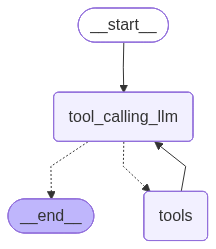

In [26]:
##StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition will route to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition will route to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the Graph
graph = builder.compile()

## Display the Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [27]:
response = graph.invoke({"messages": "Give the recent news on AI in India and What is 2 multiplied by 81"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give the recent news on AI in India and What is 2 multiplied by 81
================================== Ai Message ==================================
Tool Calls:
  tavily_search (spv0m8aad)
 Call ID: spv0m8aad
  Args:
    query: Recent news on AI in India
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent news on AI in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/02/17/india-bids-to-attract-over-200b-in-ai-infrastructure-investment-by-2028/", "title": "India bids to attract over $200B in AI infrastructure investment by 2028 - TechCrunch", "score": 0.875031, "published_date": "Tue, 17 Feb 2026 14:13:54 GMT", "content": "The effort is backed by recent policy decisions aimed at making India a more attractive base for AI computing,

### Adding Memory in Agentic AI

In [28]:
response = graph.invoke({"messages": "Hii ! My name is Piyush"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hii ! My name is Piyush
================================== Ai Message ==================================

Hello Piyush! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [29]:
response = graph.invoke({"messages": " what is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

 what is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


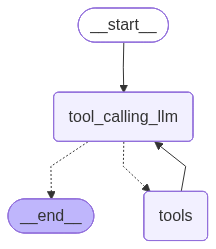

In [30]:
##StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## Initialize the memory saver
memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition will route to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition will route to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the Graph
graph = builder.compile(checkpointer=memory)

## Display the Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [31]:
config= {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"Hi! My name is Piyush"},config = config)

response["messages"][-1].content

"Hello Piyush! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [32]:
response = graph.invoke({"messages":"Hi! What is my Name ?"},config = config)

response["messages"][-1].content

'Your name is Piyush.'

### Streaming


In [33]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [34]:
def superbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

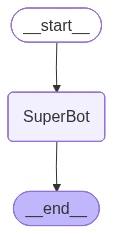

In [35]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edge
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

## Compile
graph_builder= graph.compile(checkpointer=memory)

## Display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [36]:
## Invocation

config = {"configurable":{"thread_id":"1"}}

response = graph_builder.invoke({"messages":"Hi! My name is Piyush and I love to play Basketball"},config)

response['messages'][-1].content

"Hi Piyush! It's great to meet you! Basketball is an exciting sport, and it's awesome that you're passionate about it. What position do you like to play? Are you more of a shooter, a point guard, or do you like to dominate in the paint?"

### Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.


In [37]:
# Create a Thread
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({'messages': "Hi, My name is Piyush and I like Basketball"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Piyush! Nice to meet you! Basketball is an exciting sport, isn't it? Who's your favorite team or player? Are you a fan of the NBA or do you follow any other basketball leagues?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 47, 'total_tokens': 92, 'completion_time': 0.172932117, 'completion_tokens_details': None, 'prompt_time': 0.002139465, 'prompt_tokens_details': None, 'queue_time': 0.050485073, 'total_time': 0.175071582}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7f7c-0948-7770-80d4-f2932e00f264-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 45, 'total_tokens': 92})]}}


In [38]:

for chunk in graph_builder.stream({'messages': "Hi, My name is Piyush and I like Basketball"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Piyush and I like Basketball', additional_kwargs={}, response_metadata={}, id='6a31a664-1728-481b-9b7a-00f2a44ac0ce'), AIMessage(content="Hi Piyush! Nice to meet you! Basketball is an exciting sport, isn't it? Who's your favorite team or player? Are you a fan of the NBA or do you follow any other basketball leagues?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 47, 'total_tokens': 92, 'completion_time': 0.172932117, 'completion_tokens_details': None, 'prompt_time': 0.002139465, 'prompt_tokens_details': None, 'queue_time': 0.050485073, 'total_time': 0.175071582}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7f7c-0948-7770-80d4-f2932e00f264-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 45

In [39]:
# Create a Thread
config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({'messages': "Hi, My name is Piyush and I like Basketball"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Piyush! Basketball is an exciting sport, isn't it? Who's your favorite team or player? Are you more into the NBA or do you follow other leagues like college basketball or international competitions?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 47, 'total_tokens': 94, 'completion_time': 0.115440904, 'completion_tokens_details': None, 'prompt_time': 0.001682885, 'prompt_tokens_details': None, 'queue_time': 0.049279095, 'total_time': 0.117123789}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7f7d-e8a8-7d23-8a21-fa2a820ecc42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 47, 'total_tokens': 94})]}}


In [40]:
for chunk in graph_builder.stream({'messages': "I also like Volleyball"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Piyush and I like Basketball', additional_kwargs={}, response_metadata={}, id='284af308-9e43-4a04-9328-60a97a9c312d'), AIMessage(content="Nice to meet you, Piyush! Basketball is an exciting sport, isn't it? Who's your favorite team or player? Are you more into the NBA or do you follow other leagues like college basketball or international competitions?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 47, 'total_tokens': 94, 'completion_time': 0.115440904, 'completion_tokens_details': None, 'prompt_time': 0.001682885, 'prompt_tokens_details': None, 'queue_time': 0.049279095, 'total_time': 0.117123789}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7f7d-e8a8-7d23-8a21-fa2a820ecc42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i

In [44]:
# Create a Thread
config = {"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream_events({'messages': "Hi, My name is Piyush and I like Basketball"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Piyush and I like Basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019c7f81-228f-7422-9b67-18290ba0f9bc', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Piyush and I like Basketball', additional_kwargs={}, response_metadata={}, id='1211f569-1b3d-4312-95ba-c7e179237847'), AIMessage(content="Nice to meet you, Piyush! Basketball is an exciting sport, isn't it? Who's your favorite team or player? Are you more into the NBA, college basketball, or do you enjoy playing the game yourself?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 47, 'total_tokens': 94, 'completion_time': 0.126265754, 'completion_tokens_details': None, 'prompt_time': 0.004728898, 'prompt_tokens_details': None, 'queue_time': 0.048275202, 'total_time': 0.130994652}, 'model_name': 'llama-3.